> mean(), median(), mode central tendencies
> Merkezi eğilim: Veri nerede toplanıyor? Yayılım: Veri ne kadar dağınık?

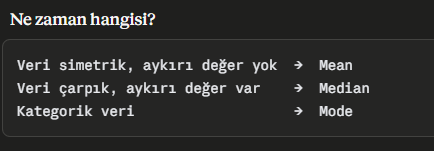


> Gerçek hayat örneği: Türkiye'de ortalama maaş mı, medyan maaş mı daha anlamlı? Medyan — çünkü çok yüksek maaşlı birkaç kişi ortalamayı yukarı çeker, ama medyan bundan etkilenmez.

In [11]:
import pandas as pd
import numpy as np


#mean
# !Problemi: Aykırı değerlerden çok etkilenir. 100 olmasaydı mean 25'ti.
df = pd.DataFrame([10, 30, 30, 40, 100]) # <== mean 40
df.mean()

0    42.0
dtype: float64

In [12]:
#median
df.median() # median 30 
# !Sıralı dizinin tam ortası. Aykırı değerden etkilenmez. Emlak fiyatları, maaş verileri için median daha sağlıklı.

0    30.0
dtype: float64

In [ ]:
# Eger cift ise [2, 3, 4, 2, 5, 3] ortadaki iki tane sayi eklenir we 2 bolunur 4+2=6/2=3
pd.DataFrame([2, 3, 4, 2, 5, 3]).median() # 3

0    3.0
dtype: float64

In [15]:
#mode
df.mode()
# !En çok tekrar eden değer. Kategorik veride kullanılır.

,0
0,30


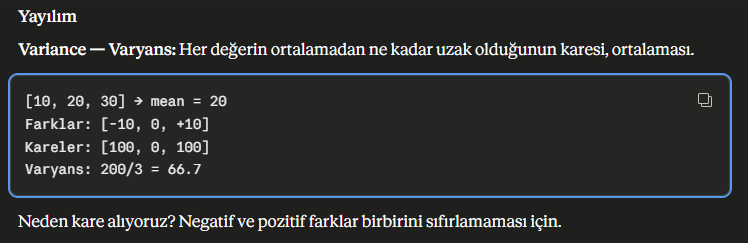

In [ ]:
#variance
df_var = pd.DataFrame([20, 30, 30, 20])
df_var.mean()

# her bir elementden mean ayiriyoruz
# mean is 25

# [20 - 25] = -5
# [30 - 25] = 5
# [30 - 25] = 5
# [20 - 25] = -5
-5 + 5 + 5 + -5 # => 0 in total
# !Sorun şu:  Her veri setinde ortalamadan sapmaların toplamı zaten 0 çıkar.

# !Bu yüzden: Sadece farkları toplarsak yayılımı ölçemeyiz.

# !Neden kare alıyoruz?

# !Negatifleri yok etmek için.
[-5, 5, 5, -5] #square is [25, 25, 25, 25]
[25, 25, 25, 25]

# Artık: negatif yok, pozitif yok, hepsi pozitif katkı yapıyor
[100] # in total
# !So
100 / 4 # ==> 25

# Verilerin ortalamadan ne kadar uzaklaştığını gösteriyor
np.var(df_var) # => 25 population
df_var.var()  # !=> 33.3 sample  ==> pandas automatically (default) use ddof=1 kullaniyor
df_var.var(ddof=0) # ! in this case it is 25 as population ddof=0

0    25.0
dtype: float64

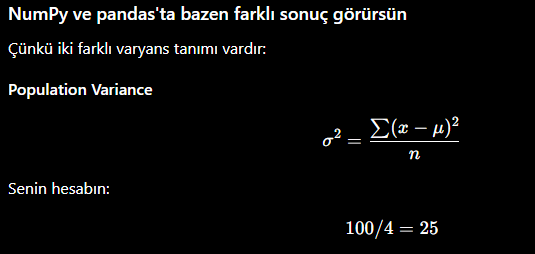
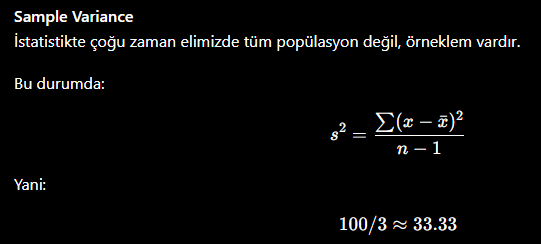

In [ ]:
class_a = pd.DataFrame([68, 69, 70, 71, 72])


In [38]:
import math

In [39]:
class_a.mean()
68 - 70 # -2
69 - 70 # -1
70 - 70 # 0
71 - 70 # 1
72 - 70 # 2
# in total 0
[4, 1, 0, 1, 4] # squared 10
10 / 5 # 2 koku de 1.41
x = 10 /5
math.sqrt(x)

1.4142135623730951

In [35]:
class_b = pd.DataFrame([20, 40, 70, 100, 120])

In [40]:
class_b.mean()
20 - 70 # -50
40 - 70 # -30
70 - 70 # 0
100 - 70 # 30
120 - 70 # 50
# in total 0
[2500, 900, 0, 900, 2500] # squared total 6800
y = 6800 / 5 # 1360
math.sqrt(y)

36.87817782917155

In [44]:
np.var(class_a) < np.var(class_b)

np.True_

In [46]:
np.var(class_b)

np.float64(1360.0)

In [45]:
np.var(class_a)

np.float64(2.0)

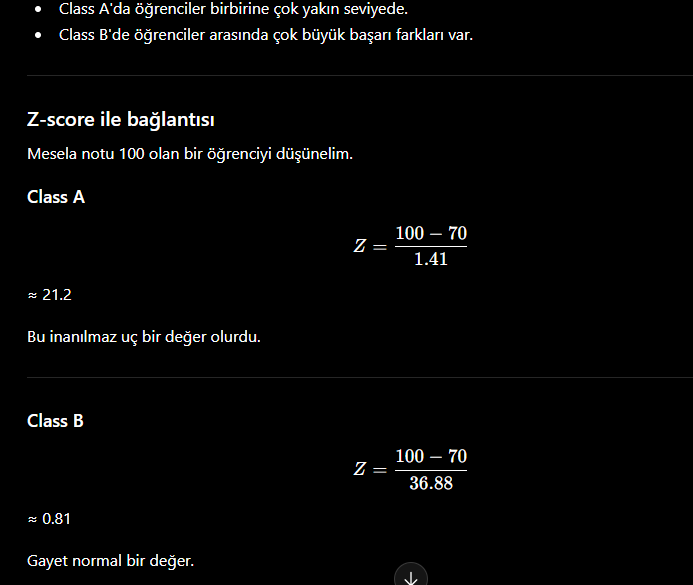

In [41]:
# So variance is not mean it. it variation of data  

In [ ]:
# Peki neden standart sapma daha popüler?

# Varyansın bir problemi var.

# Boy (cm)
a = [170, 180, 190] # variance is 66.7
np.var(a) 
# ama boyun birimi cm variance birimi cm2, so 66.7 boy uzunlugu gibi yorumlanamaz
# bu yuzden karakok square alinir
math.sqrt(np.var(a))

# veriler ortalamadan 8,16 civarinda sapiyor


8.16496580927726

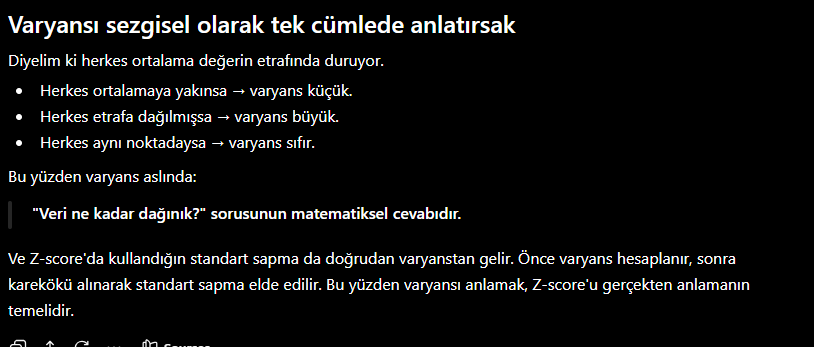
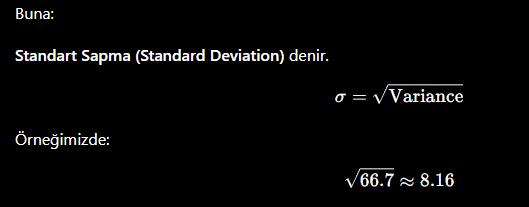


> Std - standard deviation - Varyansın birimsiz hali. "Veriler ortalamadan ortalama X birim uzakta" demek.
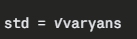

In [ ]:
std = math.sqrt(np.var(class_a)) # varyansin birimsiz hali
std
# Std küçük → veriler ortalamaya yakın, tutarlı.
# Std büyük → veriler çok dağınık, değişken.

1.4142135623730951

In [ ]:
std = math.sqrt(np.var(class_b)) # sample kullaniyor ddof = 0
print(std)
class_b.std() # population as a defalut ddof = 1

36.87817782917155


0    41.231056
dtype: float64

> IQR Bir veri setindeki orta %50’lik kısmın yayılımını ölçer.
- Verinin yayılımını ölçer
- Aykırı değerleri (outlier) bulmak için kullanılır
- Standart sapmaya göre aykırı değerlere daha dayanıklıdır

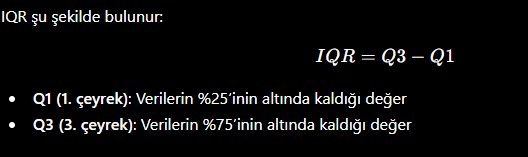
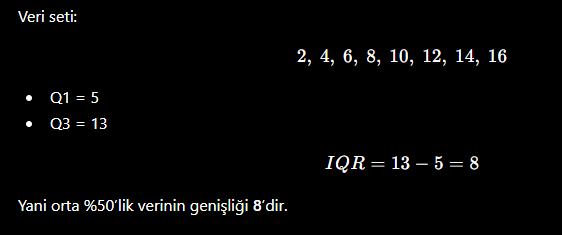
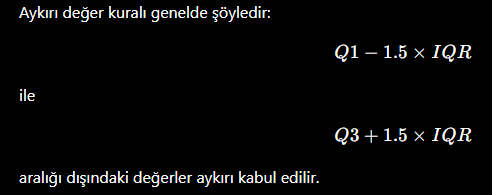

In [94]:
iqr = pd.DataFrame([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
iqr.describe().T

,count,mean,std,min,25%,50%,75%,max
0,10.0,55.0,30.276504,10.0,32.5,55.0,77.5,100.0


In [ ]:
# [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
iqr.mean()
iqr.std()
iqr.var()


iqr.median() # <=== in describe() method 50% is median() == Q2, yani 50 ve 60. 50+60 =110/2=55 so Q2 is 55

# [10, 20, 30, 40, 50] => Q1 == 30
# [60, 70, 80, 90, 100] => Q3 == 80
# IQR = Q3 - Q1, IQR = 80 - 30 = 50
# but in pandas iqr.quantile(0.25) will give 32.5 and iqr.quantile(0.75) will give 77.5, so IQR = 77.5 - 32.5 = 45 both of them are correct <=== Tukey
# !İstatistikte quartile hesaplamanın tek bir yöntemi yok.
# En yaygın yöntemler:
# Tukey
# Inclusive
# Exclusive
# Linear interpolation (Pandas varsayılanı)
# Hazen
# Weibull

# Bu yüzden farklı yazılımlar farklı sonuç verebilir

0    55.0
dtype: float64

In [110]:
import seaborn as sn
import matplotlib.pyplot as plt


Q1 = iqr.quantile(0.25)  # <== pandas interpolation
Q3 = iqr.quantile(0.75)
IQR = Q3 - Q1
IQR

0    45.0
dtype: float64

In [ ]:
#Whiskers show lower and upper bounds of dispersion
lower_bound = Q1 - 1.5 * IQR # 32.5
# Q1 - 1.5 * IQR == 32.5 - 1.5 * 45 = 32.5 - 67.5 = -35
print(lower_bound)

upper_bound = Q3 + 1.5 * IQR
#Q3 + 1.5 * IQR == 77.5 + 1.5 * 45 = 77.5 + 67.5 = 145
print(upper_bound)
#  -35 ----- 145

0   -35.0
dtype: float64
0    145.0
dtype: float64


145.0

In [ ]:
# just for chekc sqrt
import math
x = 239
math.sqrt(x) # or ** 0.5 

15.459624833740307

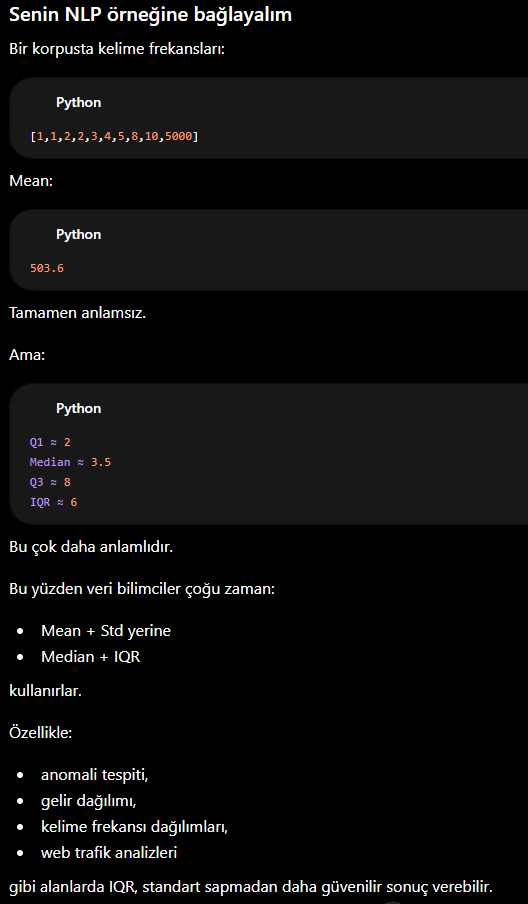

In [ ]:
nlp = pd.DataFrame([1,1,2,2,3,4,5,8,10,5000])

Q1 = nlp.quantile(.25)
Q3 = nlp.quantile(.75)
IQR = Q3 - Q1

nlp.describe().T
print(IQR) # kutunun genisligi

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(lower_bound)
print(upper_bound)
# -5.9 -------- 15.1   50000 is outliers

0    5.25
dtype: float64
0   -5.875
dtype: float64
0    15.125
dtype: float64


Bu yüzden IQR:

- Outlier'lara karşı dayanıklıdır.
- Maaş analizi
- Gelir analizi
- Satış analizi
- NLP'de kelime frekansları
- Sensör verileri
gibi sağa çarpık (skewed) dağılımlarda çok kullanılır.

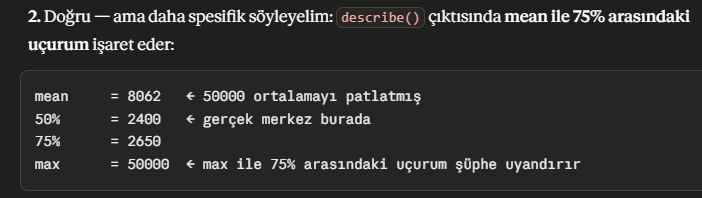

> Verilerin nasıl yayıldığını gösteren yapıya distribution denir.

> mean, variance, std, IQR, z-score -> bunlarin hepsi bir dagilimi anlamak icin kullanilan araclar

(array([1., 0., 1., 0., 0., 3., 0., 1., 0., 1.]),
 array([68. , 68.4, 68.8, 69.2, 69.6, 70. , 70.4, 70.8, 71.2, 71.6, 72. ]),
 <BarContainer object of 10 artists>)

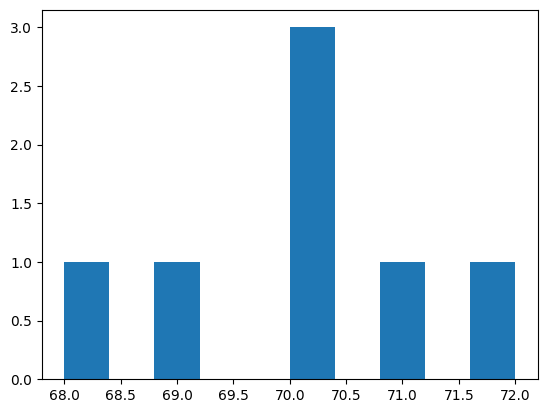

In [ ]:
# Distribution

# Neden kritik? Çünkü ML modellerinin büyük çoğunluğu verinin normal dağıldığını varsayar.
# Verin normal dağılmıyorsa model yanlış çalışır — bunu anlayamazsan hatalı sonuçlar üretirsin.

histo = pd.DataFrame([68,69,70,70,70,71,72])
plt.hist(histo)

# cogu deger ortada toplanmis -> buna dar dagilim denir

(array([1., 0., 1., 0., 1., 0., 1., 0., 1., 1.]),
 array([ 20.,  30.,  40.,  50.,  60.,  70.,  80.,  90., 100., 110., 120.]),
 <BarContainer object of 10 artists>)

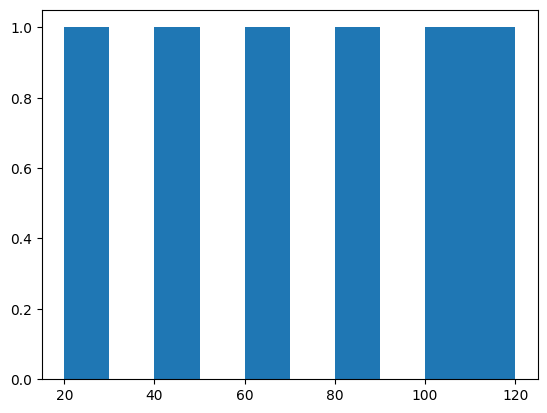

In [ ]:
histo = pd.DataFrame([20,40,60,80,100,120])
plt.hist(histo)
# degerler her yere yayilmis -> bu daha genis bir dagilimdir

# ! iki veri setinin de ortalamasi ayni == 70 ama davranis tamamen farkli, bu farki da distribution gosteriyor 

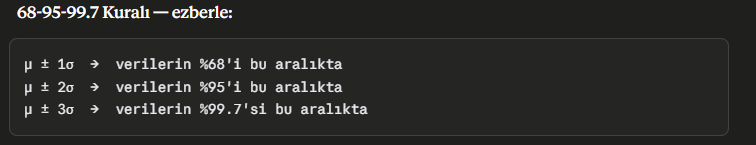

In [ ]:
# Normal Dağılım
# Simetrik, çan şeklinde. Cogu veri ortada bulunur
# !Ortalama = Medyan = Mod.
# Pratikte ne işe yarar? Bir değer μ + 3σ dışındaysa — büyük ihtimalle aykırı değer.
# en meshur olani
# insan boylari - IQ skorlari - olcum hatalari -> yaklasik normal dagilir


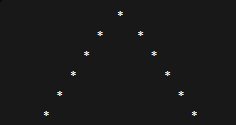

In [ ]:
# Z - score neden calisiyor?
# Cunku z-score normal dagilima dayanir
# %68 veri ±1 std içinde
# %95 veri ±2 std içinde
# %99.7 veri ±3 std içinde

# ! |Z| > 3  => anomali kabul edilir

In [ ]:
# Uniform distribution
# Her şey eşit olasılıklı

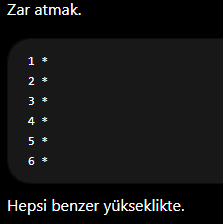

In [ ]:
# Right Skewed Distribution
# !Data Science'ta en sık göreceğin dağılım.
# ornek: right skewed maaslar, ev fiyatlari, siparis tutarlari -> cogu insan dusuk, orta gelirli, az sayida insan cok zengin
# sag tarafta uzun kuyruk vardir
# left skewed -> sinav notlari -> cogu yuksek, azi dusuk


# ML icin neden onemli? linear regression, right skewed distribution da kotu calisir, cozum
# df['tutar_log'] = np.log1p(df['tutar']) -> log1p sağa çarpıklığı düzeltir 

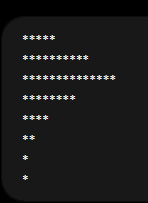
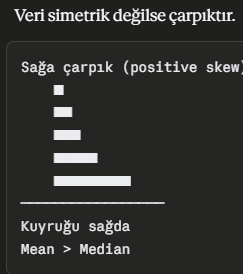
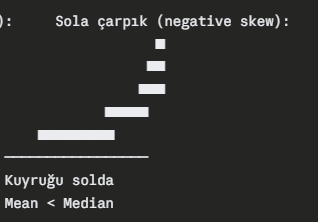

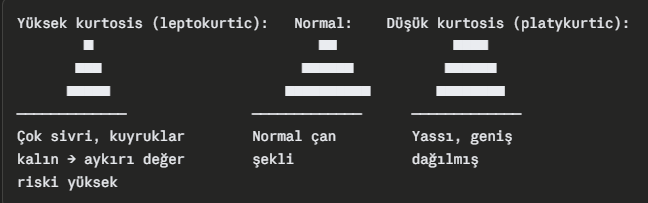

In [142]:
# Fintech'te onemli - dolandiricilik islemleri genelde yuksek kurtosis gosterir


# import scipy.stats as stats

cars = pd.read_csv('../data_analysis/sources/cars.csv')
cars.head(5)

cars['disp'].skew() # if 0'a yakin -> simetrik, pozitif -> right skewed, negatif -> left skewed

cars['disp'].kurtosis() # if 0'a yakin -> normal, pozitif -> sivri, kalin kuyruk, negatif -> yassi


np.float64(-1.0675234001434708)

In [ ]:
# if skew > 1 or < -1 -> log/sqrt apply
# if kurtosis high -> outliers value doubt, IQR check
# p-value < 0.05 -> normal dagilim degil, donusum gerekli

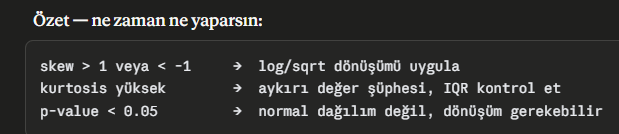

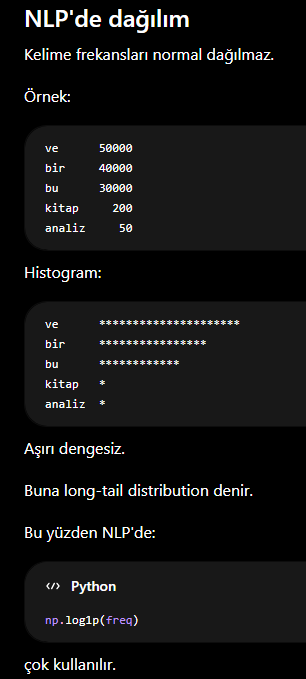

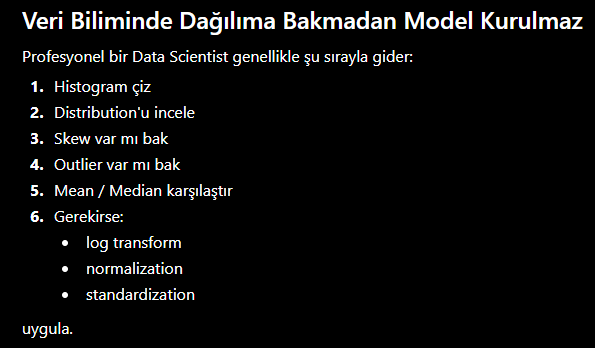